In [8]:
!mamba install pandas numpy matplotlib seaborn scikit-learn

mambajs 0.21.1

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn, scikit-learn
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 3.953 seconds
  Name                Version    Build                Channel
---------------------------------------------------------------------------
+ brotli-python       1.2.0      py313ha26e73d_2      emscripten-forge-4x
+ certifi             2026.5.20  pyhd8ed1ab_0         conda-forge
+ charset-normalizer  3.4.7      pyhd8ed1ab_0         conda-forge
+ idna                3.17       pyhcf101f3_0         conda-forge
+ joblib              1.5.3      py313h1804a44_3      emscripten-forge-4x
+ pandas              3.0.3      np23py313h1e705a5_0  emscripten-forge-4x
+ patsy               1.0.2      py313h1804a44_3      emscripten-forge-4x
+ pysocks             1.7.1      py313h1804a44_3      emscripten-forge-4x
+ python-tzdata       2026.2     pyhd8ed1ab_0         conda-forge
+ r

Show first 5 rows!!
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   Av

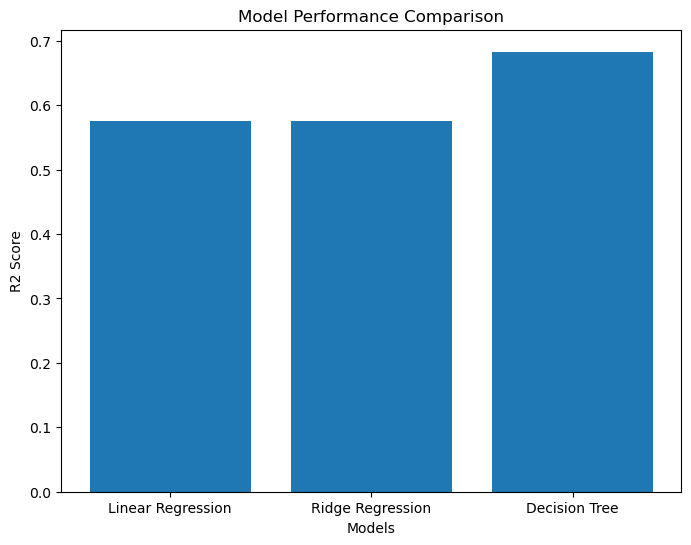

               Model      RMSE  R2 Score
0  Linear Regression  0.745581  0.575788
1   Ridge Regression  0.745557  0.575816
2      Decision Tree  0.644568  0.682948


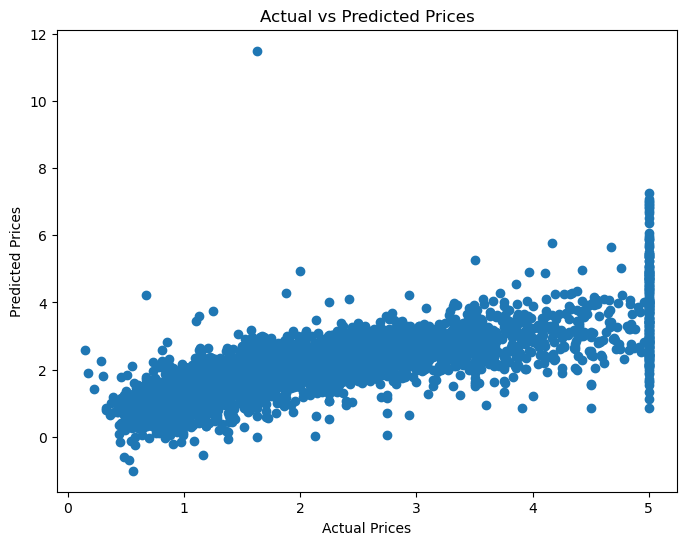

Baseline RMSE: 0.7037294974840077
Baseline R2: 0.622075845135081
Cross Validation Scores:
[0.27093461 0.41372445 0.43912441 0.23566991 0.41875969]
Average CV Score: 0.355642615410327
Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best CV Score:
0.7100830403599112
Tuned Model RMSE: 0.6390654005312799
Tuned Model R2: 0.6883380738855668
           Model      RMSE  R2 Score
0  Baseline Tree  0.703729  0.622076
1     Tuned Tree  0.639065  0.688338


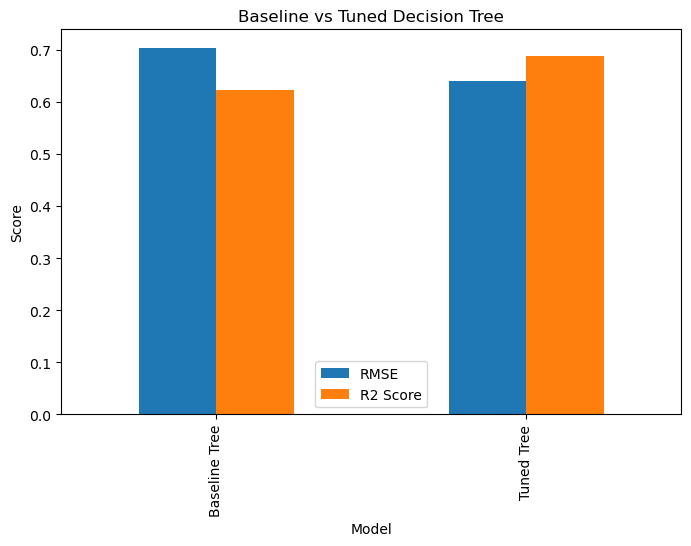

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_squared_error, r2_score

#Load Dataset
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)

#Target column
df['Price'] = housing.target

print("Show first 5 rows!!")
print(df.head())
#Dataset Info
print(df.info())
print(df.describe())
print(df.isnull().sum())

X = df.drop('Price', axis=1)
y = df['Price']

#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

#Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
#Linear Regression Model
linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)
linear_pred = linear_model.predict(X_test_scaled)

linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_r2 = r2_score(y_test, linear_pred)

print("Linear Regression RMSE:", linear_rmse)
print("Linear Regression R2 Score:", linear_r2)

#Ridge Regression Model
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_scaled, y_train)
ridge_pred = ridge_model.predict(X_test_scaled)

ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression RMSE:", ridge_rmse)
print("Ridge Regression R2 Score:", ridge_r2)

#Tree Regression Model
tree_model = DecisionTreeRegressor(max_depth=10,random_state=42)

tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)


tree_rmse = np.sqrt(mean_squared_error(y_test, tree_pred))
tree_r2 = r2_score(y_test, tree_pred)

print("Decision Tree RMSE:", tree_rmse)
print("Decision Tree R2 Score:", tree_r2)


#Comparing all models
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Ridge Regression',
        'Decision Tree'],
    'RMSE': [
        linear_rmse,
        ridge_rmse,
        tree_rmse ],
    'R2 Score': [
        linear_r2,
        ridge_r2,
        tree_r2 ]
})

plt.figure(figsize=(8,6))

plt.bar(results['Model'], results['R2 Score'])

plt.xlabel("Models")
plt.ylabel("R2 Score")

plt.title("Model Performance Comparison")

plt.show()

print(results)

#plot
plt.figure(figsize=(8,6))
plt.scatter(y_test, linear_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()

baseline_tree = DecisionTreeRegressor(random_state=42)

baseline_tree.fit(X_train, y_train)

baseline_pred = baseline_tree.predict(X_test)

baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

print("Baseline RMSE:", baseline_rmse)
print("Baseline R2:", baseline_r2)

#Cross Validation
cv_scores = cross_val_score(
    baseline_tree,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("Cross Validation Scores:")
print(cv_scores)

print("Average CV Score:", cv_scores.mean())

#Hyperparameter
param_grid = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("Best CV Score:")
print(grid_search.best_score_)

best_tree = grid_search.best_estimator_

best_tree.fit(X_train, y_train)

best_pred = best_tree.predict(X_test)

best_rmse = np.sqrt(mean_squared_error(y_test, best_pred))
best_r2 = r2_score(y_test, best_pred)

print("Tuned Model RMSE:", best_rmse)
print("Tuned Model R2:", best_r2)

#Compare Baseline vs Tuned Model
comparison = pd.DataFrame({
    'Model': ['Baseline Tree', 'Tuned Tree'],
    'RMSE': [baseline_rmse, best_rmse],
    'R2 Score': [baseline_r2, best_r2]
})

print(comparison)

comparison.set_index('Model').plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Baseline vs Tuned Decision Tree")
plt.ylabel("Score")
plt.show()
